In [4]:
import argparse
from citylearn.cost_function import CostFunction
import logging
import os
import datetime
import json
import numpy as np
import matplotlib.pyplot as plt
import pickle
from citylearn.citylearn import CityLearnEnv
from citylearn.utilities import read_json, write_json
from citylearn.data import DataSet
import shutil
import concurrent.futures
from multiprocessing import cpu_count
#from stable_baselines3 import SAC, DDPG, PPO, TD3
#from stable_baselines3.common.noise import NormalActionNoise
#from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
#from citylearn.wrappers import NormalizedObservationWrapper, StableBaselines3Wrapper
from reward.reward import AdditiveSolarPenaltyReward
#from Wrapper import ActionRescaleWrapper


In [5]:
schema_filepath= r'D:\CityLearn\5_DDPG\14_improve_code_for_future_use\4_simulation_improved_1\misc\exp_schema\sac_schema_updated.json'
env = CityLearnEnv(schema=schema_filepath)

In [17]:
read_json(schema_filepath)['observations'].keys()

dict_keys(['month', 'day_type', 'hour', 'daylight_savings_status', 'outdoor_dry_bulb_temperature', 'outdoor_dry_bulb_temperature_predicted_6h', 'outdoor_dry_bulb_temperature_predicted_12h', 'outdoor_dry_bulb_temperature_predicted_24h', 'outdoor_relative_humidity', 'outdoor_relative_humidity_predicted_6h', 'outdoor_relative_humidity_predicted_12h', 'outdoor_relative_humidity_predicted_24h', 'diffuse_solar_irradiance', 'diffuse_solar_irradiance_predicted_6h', 'diffuse_solar_irradiance_predicted_12h', 'diffuse_solar_irradiance_predicted_24h', 'direct_solar_irradiance', 'direct_solar_irradiance_predicted_6h', 'direct_solar_irradiance_predicted_12h', 'direct_solar_irradiance_predicted_24h', 'carbon_intensity', 'indoor_dry_bulb_temperature', 'average_unmet_cooling_setpoint_difference', 'indoor_relative_humidity', 'non_shiftable_load', 'solar_generation', 'cooling_storage_soc', 'heating_storage_soc', 'dhw_storage_soc', 'electrical_storage_soc', 'net_electricity_consumption', 'electricity_pric

In [ ]:
['month', 'day_type', 'hour', 

'outdoor_dry_bulb_temperature', 'outdoor_dry_bulb_temperature_predicted_6h', 'outdoor_dry_bulb_temperature_predicted_12h', 'outdoor_dry_bulb_temperature_predicted_24h', 
'outdoor_relative_humidity', 'outdoor_relative_humidity_predicted_6h', 'outdoor_relative_humidity_predicted_12h', 'outdoor_relative_humidity_predicted_24h', 
'diffuse_solar_irradiance', 'diffuse_solar_irradiance_predicted_6h', 'diffuse_solar_irradiance_predicted_12h', 'diffuse_solar_irradiance_predicted_24h', 
'direct_solar_irradiance', 'direct_solar_irradiance_predicted_6h', 'direct_solar_irradiance_predicted_12h', 'direct_solar_irradiance_predicted_24h', 

'Carbon_intensity'

, 'indoor_dry_bulb_temperature', 'average_unmet_cooling_setpoint_difference', 'indoor_relative_humidity',

 'non_shiftable_load', 'solar_generation', 'electrical_storage_soc', 'net_electricity_consumption', 

'electricity_pricing', 'electricity_pricing_predicted_6h', 'electricity_pricing_predicted_12h', 'electricity_pricing_predicted_24h'
]

In [14]:
env.get_building_information()

({'solar_power': 4.0,
  'annual_dhw_demand': 0.0,
  'annual_cooling_demand': 0.0,
  'annual_heating_demand': 0.0,
  'annual_nonshiftable_electrical_demand': 9353.601,
  'dhw_storage_capacity': 1e-05,
  'cooling_storage_capacity': 1e-05,
  'heating_storage_capacity': 1e-05,
  'electrical_storage_capacity': 6.4,
  'correlations_dhw': (nan,),
  'correlations_cooling_demand': (nan,),
  'correlations_heating_demand': (nan,),
  'correlations_non_shiftable_load': (1.0,)},)

In [6]:
b = env.buildings[0]

In [10]:
b.observation_metadata

{'day_type': True,
 'hour': True,
 'direct_solar_irradiance': True,
 'direct_solar_irradiance_predicted_6h': True,
 'direct_solar_irradiance_predicted_12h': True,
 'direct_solar_irradiance_predicted_24h': True,
 'carbon_intensity': True,
 'non_shiftable_load': True,
 'solar_generation': True,
 'electrical_storage_soc': True,
 'net_electricity_consumption': True,
 'electricity_pricing': True,
 'electricity_pricing_predicted_6h': True,
 'electricity_pricing_predicted_12h': True}

In [3]:
import os 
os.path.exists(r'D:\CityLearn\11_Transfer learning\4_Building_2_transfer_to_all\1_train_building_2\results\agents\sac_agent_episode_29.pkl')

True

In [3]:
import pandas as pd

df = pd.read_csv(r'D:\CityLearn\5_DDPG\data\citylearn_challenge_2022_phase_all\Building_2.csv')
correlation_matrix = df.corr()
print(correlation_matrix['Equipment Electric Power [kWh]'].sort_values(ascending=False))


Equipment Electric Power [kWh]                   1.000000
Hour                                             0.335171
Month                                            0.071441
Day Type                                         0.060704
Solar Generation [W/kW]                          0.035686
Daylight Savings Status                               NaN
Indoor Temperature [C]                                NaN
Average Unmet Cooling Setpoint Difference [C]         NaN
Indoor Relative Humidity [%]                          NaN
DHW Heating [kWh]                                     NaN
Cooling Load [kWh]                                    NaN
Heating Load [kWh]                                    NaN
Name: Equipment Electric Power [kWh], dtype: float64


In [12]:
import json

# === CONFIG ===
schema_path = r'D:\CityLearn\9_Corelation\1_standrad DDPG\misc\schema\GCPVB_schema.json'  # update with your path

# === LOAD SCHEMA ===
with open(schema_path, 'r') as f:
    schema = json.load(f)

# === ACCESS OBSERVATION DEFINITIONS ===
observations = schema.get("observations", {})

# === CLASSIFY ===
active_obs = [name for name, config in observations.items() if config.get("active", False)]
inactive_obs = [name for name, config in observations.items() if not config.get("active", False)]

# === SUMMARY ===
print(f"🔍 Total Observations Defined: {len(observations)}")
print(f"✅ Active Observations       : {len(active_obs)}")
print(f"🚫 Inactive Observations     : {len(inactive_obs)}")

# === OPTIONAL DETAIL ===
print("\n✅ Active Observation Names:")
for name in active_obs:
    print(f"  - {name}")

print("\n🚫 Inactive Observation Names:")
for name in inactive_obs:
    print(f"  - {name}")


🔍 Total Observations Defined: 35
✅ Active Observations       : 7
🚫 Inactive Observations     : 28

✅ Active Observation Names:
  - day_type
  - hour
  - non_shiftable_load
  - solar_generation
  - electrical_storage_soc
  - net_electricity_consumption
  - electricity_pricing

🚫 Inactive Observation Names:
  - month
  - daylight_savings_status
  - outdoor_dry_bulb_temperature
  - outdoor_dry_bulb_temperature_predicted_6h
  - outdoor_dry_bulb_temperature_predicted_12h
  - outdoor_dry_bulb_temperature_predicted_24h
  - outdoor_relative_humidity
  - outdoor_relative_humidity_predicted_6h
  - outdoor_relative_humidity_predicted_12h
  - outdoor_relative_humidity_predicted_24h
  - diffuse_solar_irradiance
  - diffuse_solar_irradiance_predicted_6h
  - diffuse_solar_irradiance_predicted_12h
  - diffuse_solar_irradiance_predicted_24h
  - direct_solar_irradiance
  - direct_solar_irradiance_predicted_6h
  - direct_solar_irradiance_predicted_12h
  - direct_solar_irradiance_predicted_24h
  - carbon_

In [13]:
[o for o in observations]

['month',
 'day_type',
 'hour',
 'daylight_savings_status',
 'outdoor_dry_bulb_temperature',
 'outdoor_dry_bulb_temperature_predicted_6h',
 'outdoor_dry_bulb_temperature_predicted_12h',
 'outdoor_dry_bulb_temperature_predicted_24h',
 'outdoor_relative_humidity',
 'outdoor_relative_humidity_predicted_6h',
 'outdoor_relative_humidity_predicted_12h',
 'outdoor_relative_humidity_predicted_24h',
 'diffuse_solar_irradiance',
 'diffuse_solar_irradiance_predicted_6h',
 'diffuse_solar_irradiance_predicted_12h',
 'diffuse_solar_irradiance_predicted_24h',
 'direct_solar_irradiance',
 'direct_solar_irradiance_predicted_6h',
 'direct_solar_irradiance_predicted_12h',
 'direct_solar_irradiance_predicted_24h',
 'carbon_intensity',
 'indoor_dry_bulb_temperature',
 'average_unmet_cooling_setpoint_difference',
 'indoor_relative_humidity',
 'non_shiftable_load',
 'solar_generation',
 'cooling_storage_soc',
 'heating_storage_soc',
 'dhw_storage_soc',
 'electrical_storage_soc',
 'net_electricity_consumption

In [12]:
from stable_baselines3.common.noise import NormalActionNoise
import numpy as np
action_noise = NormalActionNoise(mean=np.zeros(1), sigma=0.1 * np.ones(1))

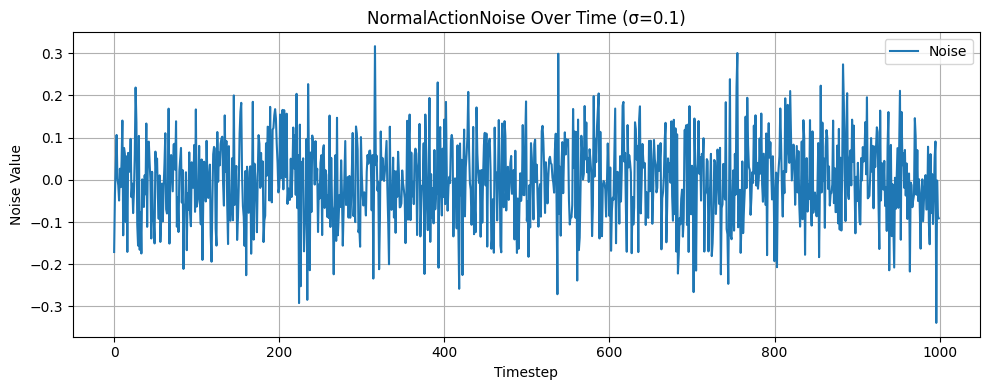

In [13]:
import matplotlib.pyplot as plt

# Generate 1000 samples of noise
noise_samples = [action_noise() for _ in range(1000)]

# Convert to a NumPy array
noise_values = np.array(noise_samples).squeeze()

# Plot
plt.figure(figsize=(10, 4))
plt.plot(noise_values, label='Noise')
plt.title("NormalActionNoise Over Time (σ=0.1)")
plt.xlabel("Timestep")
plt.ylabel("Noise Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
